<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_2/MINE_4210_ADL_202620_L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Laboratorio 2: Optimización y búsqueda de hiperparámetros**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Comprensión de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación de los datos](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Modelamiento](#scrollTo=wCS6xYiU4YYs&line=1&uniqifier=1)<br>
[4. Evaluación](#scrollTo=nnCc67Uf5urd&line=1&uniqifier=1)<br>
[5. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En este problema queremos predecir el consumo energético de los electrodomésticos (en vatios-hora) utilizando 28 variables explicativas de una vivienda de bajo consumo.

**Objetivos**
1. Preparar las características de entrada y la variable objetivo para el modelado.
2. Mejorar el modelo del laboratorio 1 con búsqueda de hiperparámetros y callbacks.


**Datos**

Los datos los puedes consultar [aquí](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction).

In [ ]:
# Librerias que necesitamos para este lab
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### **1. Comprensión de los datos**

El conjunto de datos "Appliances Energy Prediction" consta de 19735 mediciones de series temporales registradas cada 10 minutos durante aproximadamente 4.5 meses en una vivienda de bajo consumo energético situada en Bélgica. Diseñado para la regresión multivariante de series temporales, donde su objetivo principal es predecir el consumo energético de los electrodomésticos (en vatios-hora) utilizando 28 características.

Dentro de las variables predictoras encontramos métricas de temperatura interior, humedad relativa en nueve habitaciones distintas y datos metereológicos de la localidad común.

**Diccionario de datos:**

| Atributo &nbsp; &nbsp;| Descripción |
|-|-|
| date | Timestamp logged in 10-minute intervals |
| Appliances | Total energy consumption by appliances |
| lights | Energy consumption of light fixtures in the house |
| T1 | Temperature in kitchen area |
| RH_1 | Relative humidity in kitchen area |
| T2 | Temperature in living room area |
| RH_2 | Relative humidity in living room area |
| T3 | Temperature in laundry room area |
| RH_3 | Relative humidity in laundry room area |
| T4 | Temperature in office room |
| RH_4 | Relative humidity in office room |
| T5 | Temperature in bathroom |
| RH_5 | Relative humidity in bathroom |
| T6 | Temperature outside the building (north side) |
| RH_6 | Relative humidity outside the building (north side) |
| T7 | Temperature in ironing room |
| RH_7 | Relative humidity in ironing room |
| T8 | Temperature in teenager room 2 |
| RH_8 | Relative humidity in teenager room 2 |
| T9 | Temperature in parents room |
| T_out | Outdoor temperature from weather station |
| Press_mm_hg | Atmospheric pressure from weather station |
| RH_out | Outdoor humidity from weather station |
| Windspeed | Wind speed from weather station |
| Visibility | Visibility distance from weather station |
| Tdewpoint | Dew point temperature from weather station |
| rv1 | Random variable 1 (used for feature selection/filtering) |
| rv2 | Random variable 2 (used for feature selection/filtering) |

In [ ]:
# Cargamos los datos directamente del repositorio
url = 'https://raw.githubusercontent.com/nicolastibata/MINE_4210_ADL_202620/refs/heads/main/labs/Laboratorio_1/energydata_complete.csv'
data = pd.read_csv(url)
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


**Pasos de procesamiento:**
- No encontramos nulos en el conjunto de los datos, no necesitamos imputadores.
- Las variables aleatorias no las tendremos en cuenta ya que se usaron para un proceso de regresión anterior. Así como `date`, ya que nuestra tarea no es basada en series temporales, para eso más adelante usaremos un modelo secuencia como un LSTM.
- Las variables metereológicas contienen rangos dispersos en comparación con las variables de vivienda, usaremos un normalizador.

### **2. Preparación de los datos**

**OJO acá agregamos variables temporales que pueden ser explicativas**

In [ ]:
# Iniciamos con la creación de nuestro pipeline
def engineer_date_and_drop(df):
  df_out = df.copy()

  # Aseguramos formato datetime
  dates = pd.to_datetime(df_out['date'])
  hours = dates.dt.hour

  # Creamos variables temporales
  df_out['day_of_week'] = dates.dt.dayofweek
  df_out['is_weekend'] = dates.dt.dayofweek.isin([5, 6]).astype(int)
  df_out['nsm'] = dates.dt.hour * 3600 + dates.dt.minute * 60 + dates.dt.second # Segundos desde medianoche

  # Codificamos ciclicamente las horas
  df_out['hour_sin'] = np.sin(2 * np.pi * hours / 24)
  df_out['hour_cos'] = np.cos(2 * np.pi * hours / 24)

  # Eliminar 'date' y las variables aleatorias
  cols_to_drop = ['date', 'rv1', 'rv2']
  return df_out.drop(columns=[col for col in cols_to_drop if col in df_out.columns])


preprocessing_pipeline = Pipeline([
    ('feature_engineering_and_drop', FunctionTransformer(engineer_date_and_drop)), # 1. Crear características + drop
    ('scaler_step', StandardScaler()) # 2. Escalar variables numericas
])

#Configuramos el pipeline para que mantenga la salida de los datos como Dataframe, esta es una opción que pueden utilizar
preprocessing_pipeline.set_output(transform='pandas')

preprocessing_pipeline

Pipeline(steps=[('feature_engineering_and_drop',
                 FunctionTransformer(func=<function engineer_date_and_drop at 0x7fbfb72471a0>)),
                ('scaler_step', StandardScaler())])

### **3. Modelamiento**

Seguiremos usando una arquitectura MLP **pero** con búsqueda de hiperparámetros y callbacks. Algo que sucede mucho es que nuestro modelo base no siempre genera los mejores resultados, por lo tanto podemos definir un espacio de busqueda aleatorio donde prueba diferentes combinaciones.

En este caso usamos `KerasTuner` junto a `EarlyStopping` que es el paquete de callbacks que usaremos para que nuestro entrenamiento no sea exhaustivo.

*Recordemos nuestro modelo base del lab 1*

```python
model = Sequential(name="MLP_Regression")

model.add(Input(shape=(X_train_processed.shape[1],), name='Input_Layer'))
model.add(Dense(64,activation='relu',name='Hidden_Layer'))
model.add(Dense(1,activation='linear',name='Output_Layer'))
```

In [ ]:
!pip install keras_tuner -q
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Iniciamos con la separación de nuestro dataset a entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(data.drop('Appliances', axis=1), data['Appliances'], test_size=0.2, random_state=71)
print(X_train.shape) # 28 variables predictoras
print(y_train.shape) # 1 variable target
print(X_test.shape)
print(y_test.shape)

(15788, 28)
(15788,)
(3947, 28)
(3947,)


In [ ]:
# Luego aplicamos el pipeline construido en la sección anterior
X_train_scaled = preprocessing_pipeline.fit_transform(X_train) # OJO aplicamos fit-transform al set de entrenamiento
print(X_train_scaled) # Debemos procesar los datos para que sean un dataframe y no listas de arreglos

         lights        T1      RH_1        T2      RH_2        T3      RH_3  \
16218 -0.475934  0.057812 -0.146826  0.276600  0.160009  0.369490 -0.469833   
17335 -0.475934  1.926016  1.756353  1.158623  2.175193  2.181084  1.304489   
2900   3.340241  0.722062  1.282439  0.843832  0.839118 -0.196166  2.235030   
5551  -0.475934 -1.056884 -1.024444 -1.011459 -0.750392 -1.052659 -0.323189   
8793   0.796124 -0.745516 -1.851913 -0.616069 -1.899466 -1.138094 -1.797312   
...         ...       ...       ...       ...       ...       ...       ...   
15583 -0.475934 -0.502650 -1.678897 -0.752935 -1.472972  0.157681 -1.305938   
17704 -0.475934  2.741798  0.630494  2.924191 -0.580615  3.397119 -0.311343   
9768  -0.475934 -0.309602 -0.524620 -0.666253 -0.233678  0.207518 -0.733691   
11275  2.068183  0.120085  0.076340 -0.342338  0.511866  0.302210 -0.108212   
12205  0.796124  0.250859  0.511806  0.034804  0.888329  0.705893 -0.334449   

             T4      RH_4        T5  ...  Press_mm_

In [ ]:
# El resultado ya está siendo generado cómo un dataframe, solo renombremos para replicar la misma lógica del lab1
X_train_processed = X_train_scaled
X_train_processed.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,day_of_week,is_weekend,nsm,hour_sin,hour_cos
16218,-0.475934,0.057812,-0.146826,0.276600,0.160009,0.369490,-0.469833,0.451664,-0.173884,0.118273,...,0.895469,0.690658,-0.427961,-1.045408,0.688165,-0.991168,-0.621098,-0.569471,1.225640,-0.706418
17335,-0.475934,1.926016,1.756353,1.158623,2.175193,2.181084,1.304489,2.022060,1.462550,2.378568,...,-0.883885,0.959292,-0.496102,0.142152,2.334803,-0.488855,-0.621098,-1.412032,0.708049,1.225610
2900,3.340241,0.722062,1.282439,0.843832,0.839118,-0.196166,2.235030,-0.477853,2.604909,-0.158927,...,-0.281780,0.892133,1.343714,-0.140600,1.610918,1.520398,1.610051,1.211945,-1.223627,0.707925
5551,-0.475934,-1.056884,-1.024444,-1.011459,-0.750392,-1.052659,-0.323189,-1.402478,-0.585870,-1.409636,...,0.527017,1.295084,-0.836809,-1.186784,-0.962451,0.515772,-0.621098,-0.834276,1.415092,0.000753
8793,0.796124,-0.745516,-1.851913,-0.616069,-1.899466,-1.138094,-1.797312,-0.282165,-1.414444,-0.637564,...,1.542507,-1.156199,-0.427961,2.177969,-0.660169,1.018085,1.610051,0.947140,-1.413079,0.000753


In [ ]:
# Definimos nuestra función para búsqueda de hiperparámetros
def build_model(hp):
    model = Sequential(name="MLP_Regression_Tuned")
    model.add(Input(shape=(X_train_processed.shape[1],), name='Input_Layer'))

    # Búsqueda de neuronas en la primera capa oculta
    hp_units_1 = hp.Int('units_1', min_value=96, max_value=128, step=32)
    model.add(Dense(units=hp_units_1, activation='relu', name='Hidden_Layer_1'))

    # Realizamos una búsqueda de tasa de Dropout
    # Dropout es un regularizador de overfitting para redes neuronales.
    # Es un valor porcentual donde apaga ciertas neuronas de manera aleatoria
    hp_dropout = hp.Float('dropout_1', min_value=0.0, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout))

    # Búsqueda de neuronas en la segunda capa oculta
    hp_units_2 = hp.Int('units_2', min_value=64, max_value=96, step=16)
    model.add(Dense(units=hp_units_2, activation='relu', name='Hidden_Layer_2'))

    # Condicional: Probamos si agregar una 3ra capa oculta ayuda al rendimiento
    if hp.Boolean('use_third_layer'):
        hp_units_3 = hp.Int('units_3', min_value=32, max_value=48, step=8)
        model.add(Dense(units=hp_units_3, activation='relu', name='Hidden_Layer_3'))

    # Capa de salida, al ser regresión solo dejamos una neurona
    model.add(Dense(1, activation='linear', name='Output_Layer'))

    # Búsqueda de la tasa de aprendizaje (Learning Rate)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='huber',  # 'huber' es ideal para tolerar los picos altos de consumo como en nuestro caso
        metrics=['mae', 'mse']
    )
    return model

In [ ]:
# Ya teniendo nuestra función definida, configuramos el buscador de combinaciones
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',        # Métrica objetivo a minimizar
    max_trials=10,              # Número total de combinaciones distintas a probar
    executions_per_trial=1,
    directory='tuner_results_v2',
    project_name='appliances_energy'
)

# Y congiguramos nuestro callback (EarlyStopping)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6, # Nos indica qué tanto vamos a esperar dentro de las épocas sobre la mejora de la métrica a monitorear
    restore_best_weights=True
)

In [ ]:
# Además aplicamos o entrenamos con transformación logarítimica para no ser afectados tanto por los valores altos
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Ejecutamos la búsqueda de hiperparámetros
tuner.search(
    X_train_processed, y_train_log,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Extraemos y evaluamos el mejor modelo encontrado
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print("--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(f"Neuronas Capa 1: {best_hps.get('units_1')}")
print(f"Tasa de Dropout: {best_hps.get('dropout_1')}")
print(f"Neuronas Capa 2: {best_hps.get('units_2')}")
print(f"¿Incluyó 3ra Capa?: {best_hps.get('use_third_layer')}")
if best_hps.get('use_third_layer'):
    print(f"Neuronas Capa 3: {best_hps.get('units_3')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 01m 10s]
val_mae: 0.3016606271266937

Best val_mae So Far: 0.2933787703514099
Total elapsed time: 00h 11m 28s
--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
Neuronas Capa 1: 96
Tasa de Dropout: 0.2
Neuronas Capa 2: 96
¿Incluyó 3ra Capa?: False
Learning Rate: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


**Veamos los resultados de nuestro modelo con los datos de entrenamiento**

In [ ]:
y_pred_train_log = best_model.predict(X_train_processed).flatten()
y_pred_train = np.expm1(y_pred_train_log)  # Revertir logaritmo

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)
print("\n--- Métricas de Regresión para Train ---")
print(f"MAE (Error Absoluto Medio): {mae_train:.2f} Wh")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_train:.2f} Wh")
print(f"R² Score (Coeficiente de Determinación): {r2_train:.4f}")

494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Métricas de Regresión para Train ---
MAE (Error Absoluto Medio): 33.78 Wh
RMSE (Raíz del Error Cuadrático Medio): 78.84 Wh
R² Score (Coeficiente de Determinación): 0.4129


### **4. Evaluación**

In [ ]:
# Antes de evaluar en test, debemos aplicar el mismo pipeline para este conjunto de datos
X_test_scaled = preprocessing_pipeline.transform(X_test) # OJO acá solo aplicamos el transform al set de prueba

X_test_processed = X_test_scaled
X_test_processed.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,day_of_week,is_weekend,nsm,hour_sin,hour_cos
5273,-0.475934,-1.056884,-1.375492,-1.300398,-1.111272,-0.981106,-0.499776,-1.060025,-1.184285,-0.711524,...,1.086435,0.713044,-1.245657,2.107281,-2.267033,-0.488855,-0.621098,-0.593544,1.366908,-0.365306
17938,-0.475934,1.054187,-1.149819,-0.027546,-0.430522,0.999935,-0.722430,1.337152,-1.115237,1.994336,...,0.756177,0.489183,-0.700526,0.142152,-0.298227,1.520398,1.610051,-0.762056,1.415092,0.000753
16811,-0.475934,1.496329,-0.936683,3.763634,-2.877778,1.353781,-0.701956,1.386074,-0.593542,1.236695,...,-0.398606,-2.600106,-0.087254,0.142152,0.855215,1.018085,1.610051,-0.160227,0.708049,-1.224104
2402,-0.475934,-1.866439,1.483037,-1.122472,1.422267,-1.337445,1.639238,-1.549244,1.761758,-1.282460,...,1.138109,0.936906,-0.836809,-0.847481,-0.186860,0.013458,-0.621098,-0.376885,1.000916,-0.999338
4010,-0.475934,-0.371875,1.071810,-0.027546,0.561077,0.357031,1.025020,0.065181,0.910167,-0.425905,...,-2.164480,-0.719669,3.660520,0.142152,-0.131177,-1.493482,-0.621098,0.200871,-0.364986,-1.365397


**Ahora evaluemos el modelo con los datos de test**

In [ ]:
y_pred_log = best_model.predict(X_test_processed).flatten()
y_pred = np.expm1(y_pred_log) # Regresamos a unidades originales
# Calculemos las métricas de las predicciones
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas de Regresión para Test ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} Wh")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} Wh")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Métricas de Regresión para Test ---
MAE (Error Absoluto Medio): 35.60 Wh
RMSE (Raíz del Error Cuadrático Medio): 82.51 Wh
R² Score (Coeficiente de Determinación): 0.3333


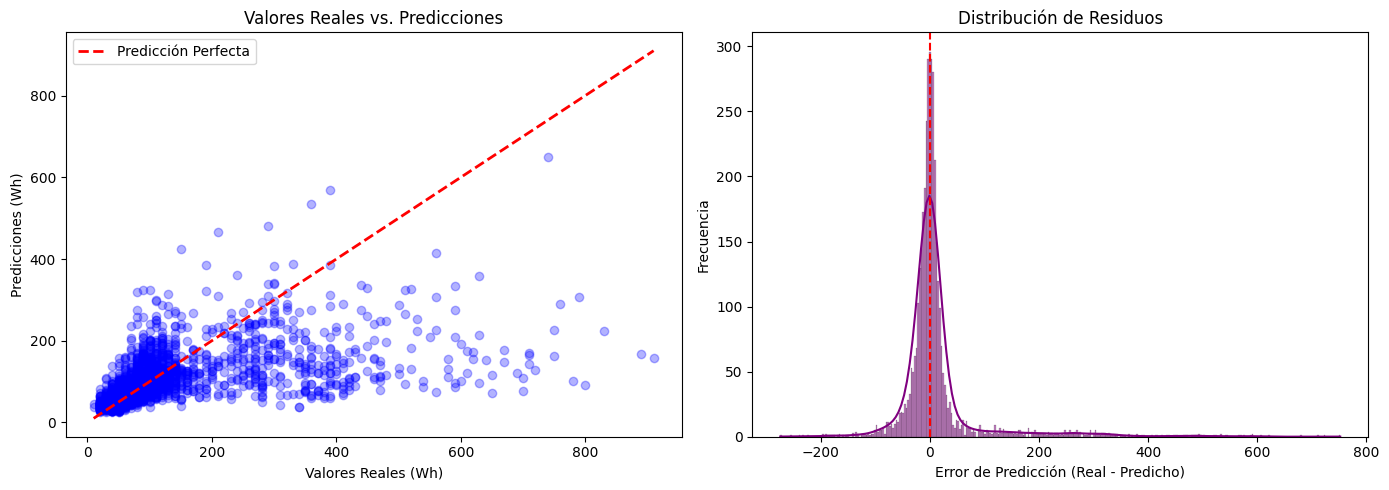

In [ ]:
plt.figure(figsize=(14, 5))
# Grafiquemos los valores reales vs los predichos
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.xlabel('Valores Reales (Wh)')
plt.ylabel('Predicciones (Wh)')
plt.title('Valores Reales vs. Predicciones')
plt.legend()

# Grafiquemos la distribución del error
plt.subplot(1, 2, 2)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Error de Predicción (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')

plt.tight_layout()
plt.show()

- Veamos que hay una sutil mejora en nuestro modelo en cuanto a la capacidad explicativa, sin embargo una arquitectura MLP no es la más adecuada para tareas de regresión.
- Es muy importante el uso de callbacks ya que esto permite que si el entrenamiento en el modelo no mejora dentro de las épocas pueda ser descartado sin que sea necesario pasar por todas las épocas definidas en el entrenamiento. Lo mismo para el Dropout, el cual nos ayuda a 'congelar' ciertas neuronas para prevenir overfitting dentro del entrenamiento.


| Conjunto de datos | Métrica | Modelo Base | Modelo Búsqueda |
|-|-|-|-|
| train | MAE | 49.91 | 33.78 |
| train | RSME | 88.86 | 78.84 |
| train | R2 Score | 0.25 | 0.41 |
| test | MAE | 50.29 | 35.60 |
| test | RMSE | 89.24 | 82.51 |
| test | R2 Score | 0.22 | 0.33 |


### **5. Preguntas**

1. Si cambiamos el `patience` a 3 o a 10, que pasa con el entrenamiento? En cuáles casos es más exhaustivo y puede demorar más?

2. En este caso usamos `EarlyStopping` como callback de entrenamiento. Cómo funciona `ReduceLROnPlateau` y el TensorBoard dentro de Keras?

3. En qué consiste el método `kt.Hyperband` o `kt.BayesianOptimization` de keras tuner? (les servirá mucho para sus entrenamientos)


